# Схема метро — пересадки як окремі станції

Та сама схема, що в slide 1, але:
- кожна пересадкова станція — **окремий кружок** у своєму кольорі лінії (більше не split-wedge);
- між парою пересадкових станцій — **видиме коротке ребро** (пунктир);
- загальне розташування не змінюється: тільки маленький офсет ±0.2–0.4 від спільного центру.

from dataclasses import dataclass
from typing import Tuple, Dict, List
import math

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [1]:
from dataclasses import dataclass
from typing import Tuple, Dict, List
import math

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
@dataclass(frozen=True)
class Line:
    code: str
    name: str
    color: str
    stations: Tuple[str, ...]


@dataclass(frozen=True)
class Transfer:
    stations: Tuple[str, str]


LINES: List[Line] = [
    Line("M1", "Холодногірсько-Заводська", "#E74C3C", (
        "Холодна гора", "Вокзальна", "Центральний ринок",
        "Майдан Конституції", "Левада", "Спортивна",
        "Заводська", "Турбоатом", "Палац Спорту",
        "Армійська", "Ім. О. С. Масельського",
        "Тракторний завод", "Індустріальна",
    )),
    Line("M2", "Салтівська", "#2C3E80", (
        "Салтівська", "Студентська", "Академіка Павлова",
        "Академіка Барабашова", "Київська", "Ярослава Мудрого",
        "Університет", "Історичний музей",
    )),
    Line("M3", "Олексіївська", "#27AE60", (
        "Перемога", "Олексіївська", "23 серпня",
        "Ботанічний сад", "Наукова", "Держпром",
        "Архітектора Бекетова", "Захисників України",
        "Метробудівників",
    )),
]

TRANSFERS: List[Transfer] = [
    Transfer(stations=("Майдан Конституції", "Історичний музей")),
    Transfer(stations=("Університет", "Держпром")),
    Transfer(stations=("Спортивна", "Метробудівників")),
]

## 2. Layout — з розщепленими пересадками

`compute_layout` повертає два словники:
- `pos` — координати кожної станції (включно з окремими позиціями для двох сторін кожної пересадки);
- `cluster_centers` — центр кожної пересадки (потрібен підписам, які прив’язані до центра).

In [3]:
class Layout:
    POLYGON_CENTER = (0.0, 0.0)
    POLYGON_RADIUS = 3.0
    STEP_EXT       = 1.5    # крок між зовнішніми станціями

    # 9 станцій циклу — рівномірно по колу проти годинникової стрілки.
    # Спортивна на 0° (справа), щоб найдовший хвіст (M1→Індустріальна) пішов праворуч.
    CYCLE_STATIONS: List[Tuple[str, float]] = [
        ("Спортивна",              0.0),
        ("Метробудівників",       40.0),
        ("Захисників України",    80.0),
        ("Архітектора Бекетова", 120.0),
        ("Держпром",             160.0),
        ("Університет",          200.0),
        ("Історичний музей",     240.0),
        ("Майдан Конституції",   280.0),
        ("Левада",               320.0),
    ]


CYCLE_STATION_SET = {s for s, _ in Layout.CYCLE_STATIONS}


def compute_layout(lines):
    red, blue, green = lines
    cx, cy = Layout.POLYGON_CENTER
    R = Layout.POLYGON_RADIUS
    step_ext = Layout.STEP_EXT

    pos: Dict[str, Tuple[float, float]] = {}

    # --- крок 1: розставити 9 станцій циклу по колу ---
    for st, angle_deg in Layout.CYCLE_STATIONS:
        a = math.radians(angle_deg)
        pos[st] = (cx + R * math.cos(a), cy + R * math.sin(a))

    def outward(st):
        x, y = pos[st]
        dx, dy = x - cx, y - cy
        m = math.hypot(dx, dy)
        return (dx / m, dy / m)

    # --- крок 2: продовжити зовнішні «хвости» РАДІАЛЬНО назовні ---
    def extend(anchor_st, line_stations, anchor_idx, indices):
        ax, ay = pos[anchor_st]
        odx, ody = outward(anchor_st)
        for i in indices:
            st = line_stations[i]
            k = abs(i - anchor_idx)
            pos[st] = (ax + k * step_ext * odx, ay + k * step_ext * ody)

    konst_i = red.stations.index("Майдан Конституції")
    sport_i = red.stations.index("Спортивна")
    univ_i  = blue.stations.index("Університет")
    derzh_i = green.stations.index("Держпром")

    extend("Майдан Конституції", red.stations,   konst_i, range(konst_i))                         # Холодна…Центральний
    extend("Спортивна",          red.stations,   sport_i, range(sport_i + 1, len(red.stations)))  # Заводська…Індустріальна
    extend("Університет",        blue.stations,  univ_i,  range(univ_i))                          # Салтівська…Ярослава Мудрого
    extend("Держпром",           green.stations, derzh_i, range(derzh_i))                         # Перемога…Наукова

    return pos

## 3. Граф

In [4]:
def build_graph(lines, transfers):
    G = nx.Graph()
    for line in lines:
        G.add_nodes_from(line.stations)
        G.add_edges_from(zip(line.stations, line.stations[1:]))
    for t in transfers:
        G.add_edge(*t.stations)
    return G

## 4. Стилі рендеру

In [5]:
class Style:
    FIGSIZE             = (22, 12)   # ширше і нижче — під полігональний layout
    STATION_SIZE        = 280
    STATION_EDGE_WIDTH  = 3
    LINE_WIDTH          = 7
    LINE_ALPHA          = 0.85

    TRANSFER_EDGE_COLOR = "#555555"
    TRANSFER_EDGE_WIDTH = 3.0
    TRANSFER_EDGE_STYLE = (0, (5, 3))
    TRANSFER_EDGE_ALPHA = 0.85

    LABEL_FONTSIZE      = 10
    TRANSFER_FONTSIZE   = 11
    TITLE_FONTSIZE      = 18
    LEGEND_FONTSIZE     = 12

## 5. Рендерингові шари

In [6]:
def setup_axes():
    fig, ax = plt.subplots(figsize=Style.FIGSIZE, facecolor="white")
    ax.set_facecolor("white")
    ax.set_axis_off()
    ax.set_aspect("equal")
    return fig, ax


def draw_lines(ax, G, pos, lines):
    """Сегменти ліній метро у кольорі лінії."""
    for line in lines:
        edges = list(zip(line.stations, line.stations[1:]))
        nx.draw_networkx_edges(
            G, pos, edgelist=edges, ax=ax,
            edge_color=line.color,
            width=Style.LINE_WIDTH,
            alpha=Style.LINE_ALPHA,
        )


def draw_transfer_edges(ax, G, pos, transfers):
    """Короткі пунктирні ребра між парами пересадкових станцій."""
    edges = [t.stations for t in transfers]
    nx.draw_networkx_edges(
        G, pos, edgelist=edges, ax=ax,
        edge_color=Style.TRANSFER_EDGE_COLOR,
        width=Style.TRANSFER_EDGE_WIDTH,
        style=Style.TRANSFER_EDGE_STYLE,
        alpha=Style.TRANSFER_EDGE_ALPHA,
    )


def draw_stations(ax, pos, color_of):
    """Усі станції — однакові: біла заливка + обводка кольором своєї лінії."""
    for st, (x, y) in pos.items():
        ax.scatter(
            x, y,
            s=Style.STATION_SIZE, c="white",
            edgecolors=color_of[st],
            linewidths=Style.STATION_EDGE_WIDTH,
            zorder=5,
        )

## 6. Підписи (анкеряться до центрів кластерів пересадок)

In [7]:
# Тільки ці станції отримують підпис.
# Для кожної задано (angle_deg, distance, ha, va):
#   angle_deg  — кут offset'а від кружечка (0=праворуч, 90=вгору, CCW);
#   distance   — відстань від центра кружечка (data units, бокс іде ще далі);
#   ha/va      — таке, щоб БЛИЖНЄ до кружечка ребро тексту було на анкері,
#                а сам напис розгортався геть від кружечка.
# Напрямки підібрано так, щоб обходити: outer extension (радіальний промінь),
# хорди до сусідніх cycle-станцій, пунктири пересадок.
LABEL_OFFSETS = {
    'Майдан Конституції':   (  0, 0.55, 'left',   'center'),
    'Університет':          (270, 0.55, 'right',  'top'),
    'Держпром':             ( 90, 0.95, 'center', 'bottom'),
    'Спортивна':            (315, 0.55, 'left',   'top'),
    'Архітектора Бекетова': (120, 0.85, 'right',  'bottom'),
    'Захисників України':   ( 80, 0.85, 'center', 'bottom'),
    'Метробудівників':      ( 40, 0.55, 'left',   'bottom'),
    'Левада':               (320, 0.85, 'left',   'top'),
}


def compute_label_position(station, pos):
    x, y = pos[station]
    angle_deg, dist, ha, va = LABEL_OFFSETS[station]
    a = math.radians(angle_deg)
    return x + dist * math.cos(a), y + dist * math.sin(a), ha, va


def _label_style(is_transfer, color):
    if is_transfer:
        return {
            'fontsize': Style.TRANSFER_FONTSIZE,
            'fontweight': 'bold',
            'color': color,
            'bbox': dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=color, alpha=0.95, linewidth=1.5),
        }
    return {
        'fontsize': Style.LABEL_FONTSIZE,
        'fontweight': 'normal',
        'color': 'black',
        'bbox': dict(boxstyle='round,pad=0.15', facecolor='white',
                     edgecolor='none', alpha=0.85),
    }


def draw_labels(ax, pos, line_of, color_of, transfers, transfer_stations, polygon_center):
    for st in pos:
        if st not in LABEL_OFFSETS:
            continue
        lx, ly, ha, va = compute_label_position(st, pos)
        style = _label_style(st in transfer_stations, color_of[st])
        ax.text(lx, ly, st, ha=ha, va=va, zorder=6, **style)

## 7. Заголовок + легенда

In [8]:
def draw_legend(ax, lines):
    handles = [
        Line2D([0], [0], color=line.color,
               linewidth=Style.LINE_WIDTH,
               label=f"{line.code} — {line.name}")
        for line in lines
    ]
    # Додаємо запис про пересадку
    handles.append(
        Line2D([0], [0], color=Style.TRANSFER_EDGE_COLOR,
               linewidth=Style.TRANSFER_EDGE_WIDTH,
               linestyle='--', label='Пересадка')
    )
    ax.legend(handles=handles, loc='upper right',
              fontsize=Style.LEGEND_FONTSIZE, framealpha=0.95, edgecolor='gray')


def draw_title(ax, G, n_transfers):
    ax.set_title(
        f"Схема Харківського метрополітену\n"
        f"{G.number_of_nodes()} станцій • "
        f"{G.number_of_edges()} з'єднань • 3 лінії • {n_transfers} пересадки",
        fontsize=Style.TITLE_FONTSIZE, fontweight='bold', pad=20,
    )

## 8. Композиція

In [9]:
def draw_schematic(G, lines, transfers, pos, savepath=None):
    color_of = {st: line.color for line in lines for st in line.stations}
    line_of  = {st: line       for line in lines for st in line.stations}
    transfer_stations = {s for t in transfers for s in t.stations}

    fig, ax = setup_axes()
    draw_lines(ax, G, pos, lines)
    draw_transfer_edges(ax, G, pos, transfers)
    draw_stations(ax, pos, color_of)
    draw_labels(ax, pos, line_of, color_of, transfers,
                transfer_stations, Layout.POLYGON_CENTER)
    draw_legend(ax, lines)
    draw_title(ax, G, len(transfers))

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, facecolor="white", bbox_inches="tight")
        print(f"Saved: {savepath}")
    plt.show()

## 9. Запуск

Stations: 30
Edges:    30
Saved: metro_schematic_split.png


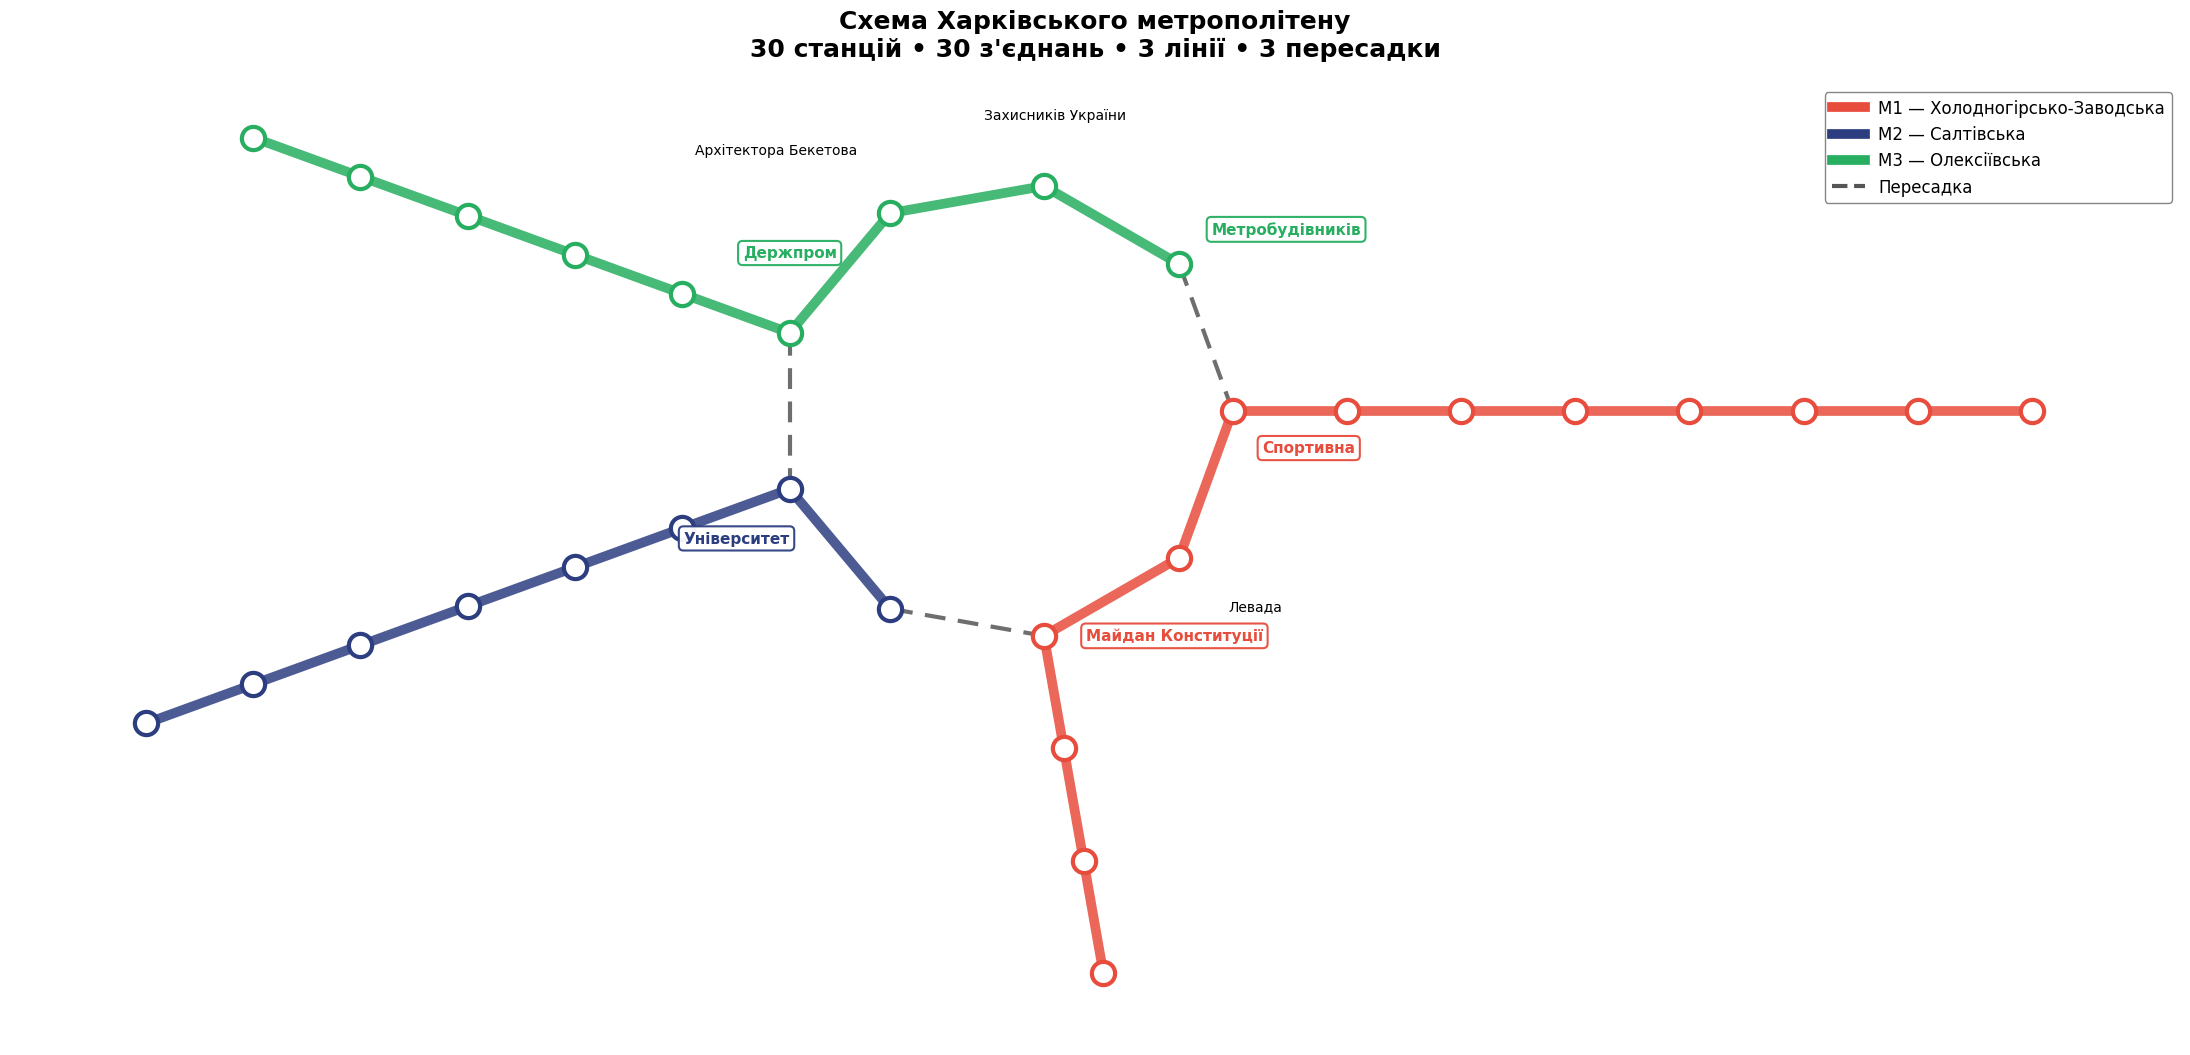

In [10]:
G   = build_graph(LINES, TRANSFERS)
pos = compute_layout(LINES)

print(f"Stations: {G.number_of_nodes()}")
print(f"Edges:    {G.number_of_edges()}")

draw_schematic(G, LINES, TRANSFERS, pos,
               savepath="metro_schematic_split.png")